# Geothermal Well Test Analysis — Worked Example

**Temperature, fluid velocity, and feed-zone interpretation** using the
`geothermal_welltest` package.

This notebook is a thin, readable walkthrough: all of the science lives in the package
(`src/geothermal_welltest/`), so each step here is one or two calls. It reproduces the figures
in `figures/` and the ranked feed-zone table.

> Rebuilt and extended from the Software Underground *Transform 2021* tutorial by
> Irene Wallis & Katie McLean. See `README.md` for background and `docs/METHODOLOGY.md`
> for the physics and equations.

**Workflow**
1. Load and QC the heating temperature/pressure profile.
2. Temperature models — boiling point for depth, gradient/curvature, feed-zone score.
3. Fluid-velocity models — forward-model a PTS dataset, invert with the cross-plot method.
4. Combine both datasets to locate and rank the feed zones.


## 0. Setup

If you have installed the package (`pip install -e .` from the repo root) the import just works.
The fallback below lets the notebook run from a clone without installing, by adding `../src`
to the path.


In [1]:
import sys, pathlib
try:
    import geothermal_welltest  # installed case
except ModuleNotFoundError:
    sys.path.insert(0, str(pathlib.Path.cwd().parents[0] / "src"))  # running from notebooks/
    sys.path.insert(0, "src")                                        # running from repo root
    import geothermal_welltest

import numpy as np
import matplotlib.pyplot as plt
from geothermal_welltest import (
    load_profile, profile_summary, run_temperature_analysis,
    build_synthetic_pts, run_velocity_analysis, combine_and_detect,
    DEFAULT_CONFIG, DEFAULT_GEOMETRY,
)
from geothermal_welltest import plotting
plotting.apply_house_style()
print("geothermal_welltest version:", geothermal_welltest.__version__)


geothermal_welltest version: 1.0.0


## 1. Load and quality-check the profile

`load_profile` reads the CSV, sorts by depth, converts bar-gauge to bar-absolute
(**`+1.01325`** — a correction over the original tutorial's `-1`), and derives the boiling
point for depth and the below-boiling margin.


In [2]:
DATA = "data/Data-Temp-Heating37days.csv"
try:
    df = load_profile(DATA)
except FileNotFoundError:
    df = load_profile("../data/Data-Temp-Heating37days.csv")  # from notebooks/
print(profile_summary(df))
df[["depth_m", "pres_barg", "pressure_bara", "temp_degC", "tsat_degC", "t_minus_tsat"]].head()


{'n_points': 94, 'depth_min_m': 0.0, 'depth_max_m': 926.4, 'temp_max_degC': 230.82, 'temp_max_depth_m': 900.7}


,depth_m,pres_barg,pressure_bara,temp_degC,tsat_degC,t_minus_tsat
0,0.0,3.929268,4.942518,10.48,151.401108,-140.921108
1,10.5,3.929268,4.942518,10.86,151.401108,-140.541108
2,20.7,3.929268,4.942518,11.63,151.401108,-139.771108
3,30.4,3.939268,4.952518,12.25,151.477097,-139.227097
4,40.3,3.949268,4.962518,12.77,151.552964,-138.782964


## 2. Temperature models

`run_temperature_analysis` computes the smoothed gradient and curvature, classifies each depth
as conductive or convective/isothermal, and builds a feed-zone score (isothermal + boiling
proximity). The dashboard shows all four temperature views on one depth axis.


Temperature-only feed-zone picks: 654 m, 762 m


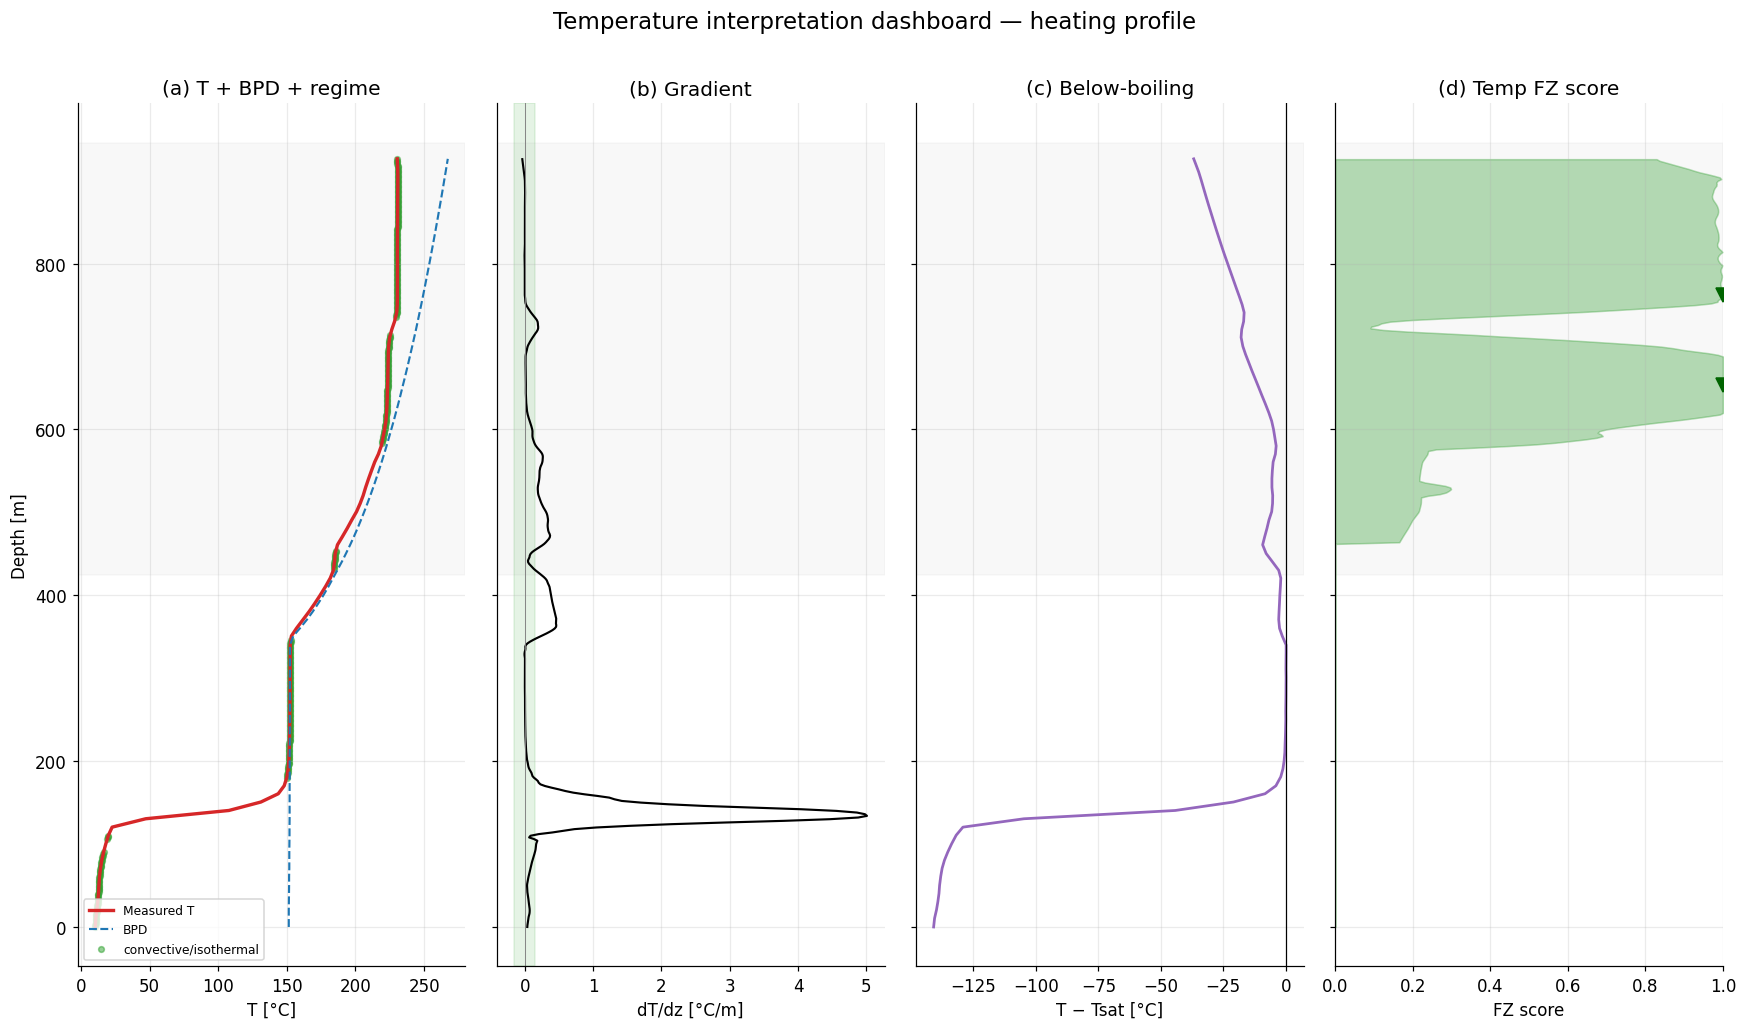

In [3]:
temp = run_temperature_analysis(df, DEFAULT_CONFIG, DEFAULT_GEOMETRY)
print("Temperature-only feed-zone picks:",
      ", ".join(f"{d:.0f} m" for d in temp.feedzone_depths))

fig = plotting.plot_temperature_dashboard(df, temp)
plt.show()


## 3. Fluid-velocity models

The raw spinner logs are not in this dataset, so we **forward-model** a physically consistent
PTS dataset from a set of feed zones (placed on the temperature-derived permeable intervals),
then **invert** it with the cross-plot method for three pump rates and apply QC. This is the
"perform a similar model" step — swap `build_synthetic_pts` for your real PTS import to run on
measured data.


In [4]:
# feed zones: (top_m, bottom_m, relative injectivity) — edit to match a real well
FEEDZONES = [
    (560, 600, 0.10), (665, 690, 0.08), (720, 745, 0.14), (748, 775, 0.24),
    (800, 835, 0.28), (852, 872, 0.11), (905, 925, 0.05),
]
PUMP_RATES = {"low (45 t/hr)": 45.0, "high (110 t/hr)": 110.0, "mid (75 t/hr)": 75.0}

rng = np.random.default_rng(7)
pts_by_rate, v_true = {}, {}
for name, rate in PUMP_RATES.items():
    pts_by_rate[name], v_true[name] = build_synthetic_pts(rate, FEEDZONES, df, rng=rng)

velocity = run_velocity_analysis(pts_by_rate, DEFAULT_CONFIG, v_true=v_true)
for name in velocity.raw:
    print(f"{name:18s}: {len(velocity.raw[name])} intervals -> {len(velocity.clean[name])} after QC")


low (45 t/hr)     : 232 intervals -> 169 after QC
high (110 t/hr)   : 232 intervals -> 149 after QC
mid (75 t/hr)     : 232 intervals -> 149 after QC


### 3.1 Cross-plot method on one interval

The intercept of tool-speed vs spinner-frequency (at frequency = 0) is the fluid velocity.


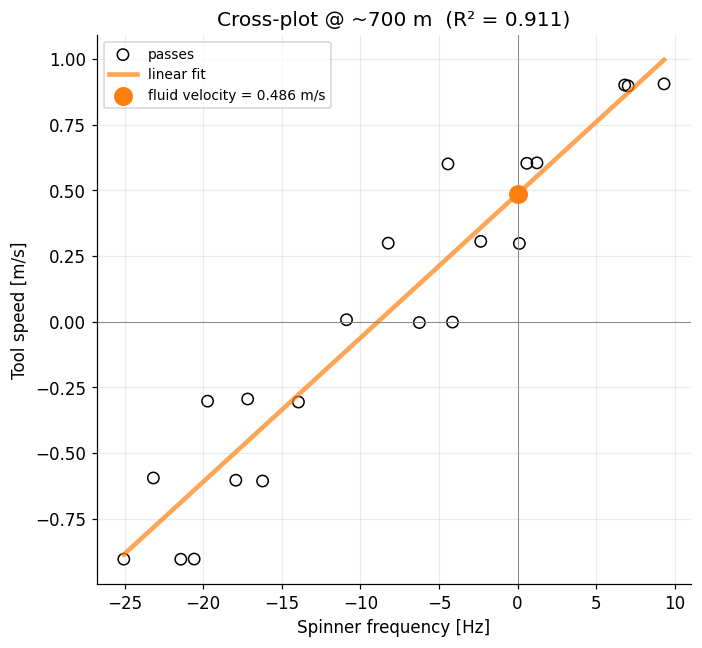

In [5]:
fig = plotting.plot_crossplot_example(pts_by_rate["high (110 t/hr)"], top=700, bottom=701)
plt.show()


### 3.2 Quality control and recovery

Left: raw inversion coloured by R². Right: cleaned velocity vs the known ground truth (dashed).
The inversion recovers the true velocity and its downward steps through each feed zone.


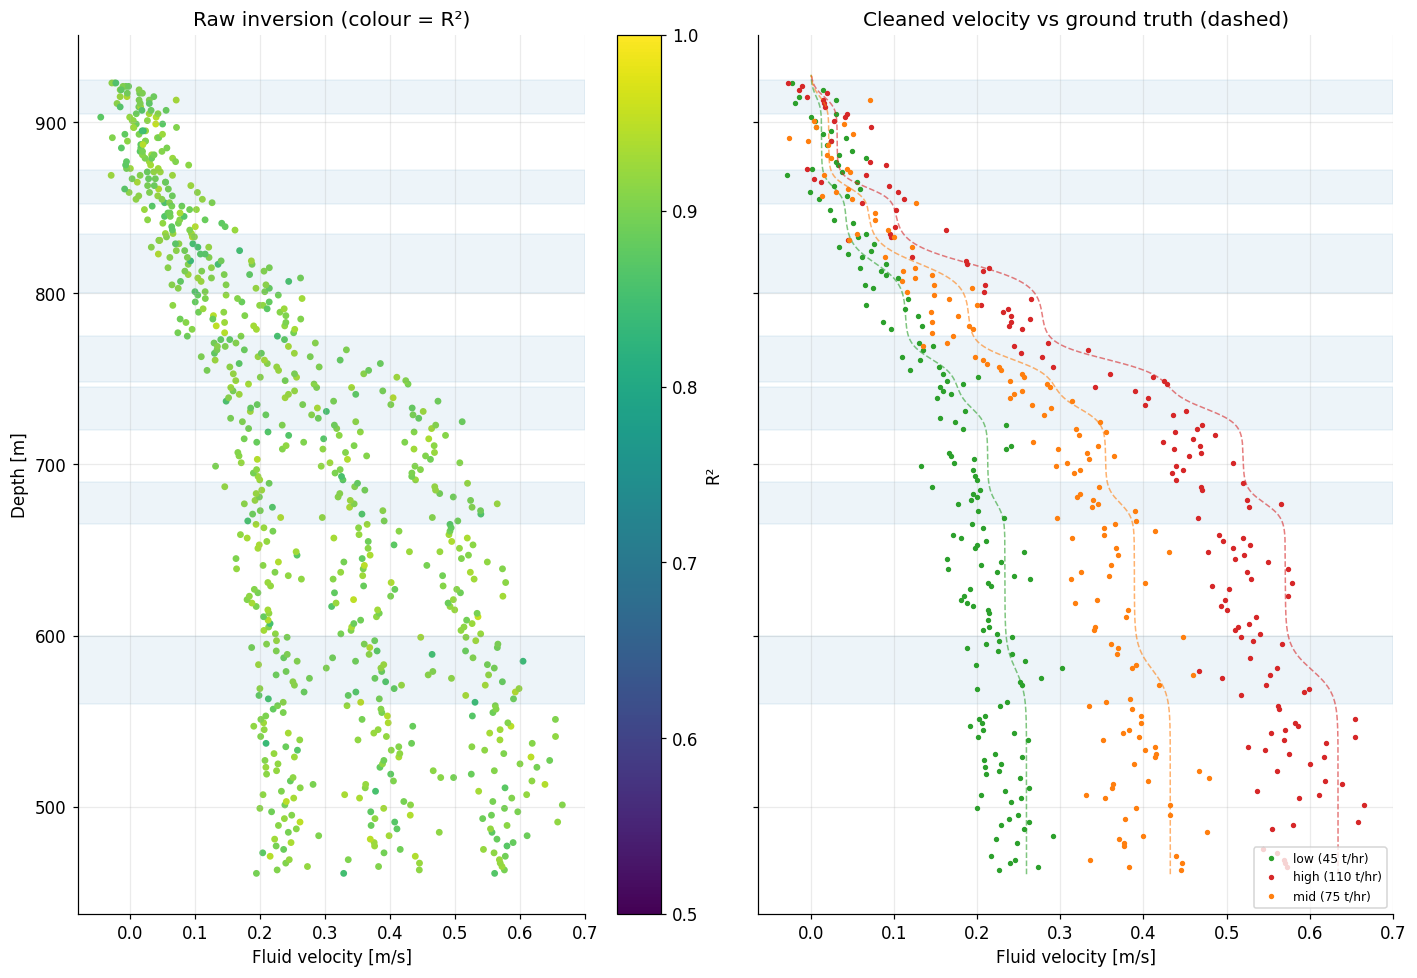

In [6]:
fig = plotting.plot_velocity_qc(velocity, FEEDZONES)
plt.show()


### 3.3 Feed-zone signal

Each feed zone removes mass, so velocity steps down and `dV/dz` peaks. Zone size scales with the
step magnitude (its relative injectivity).


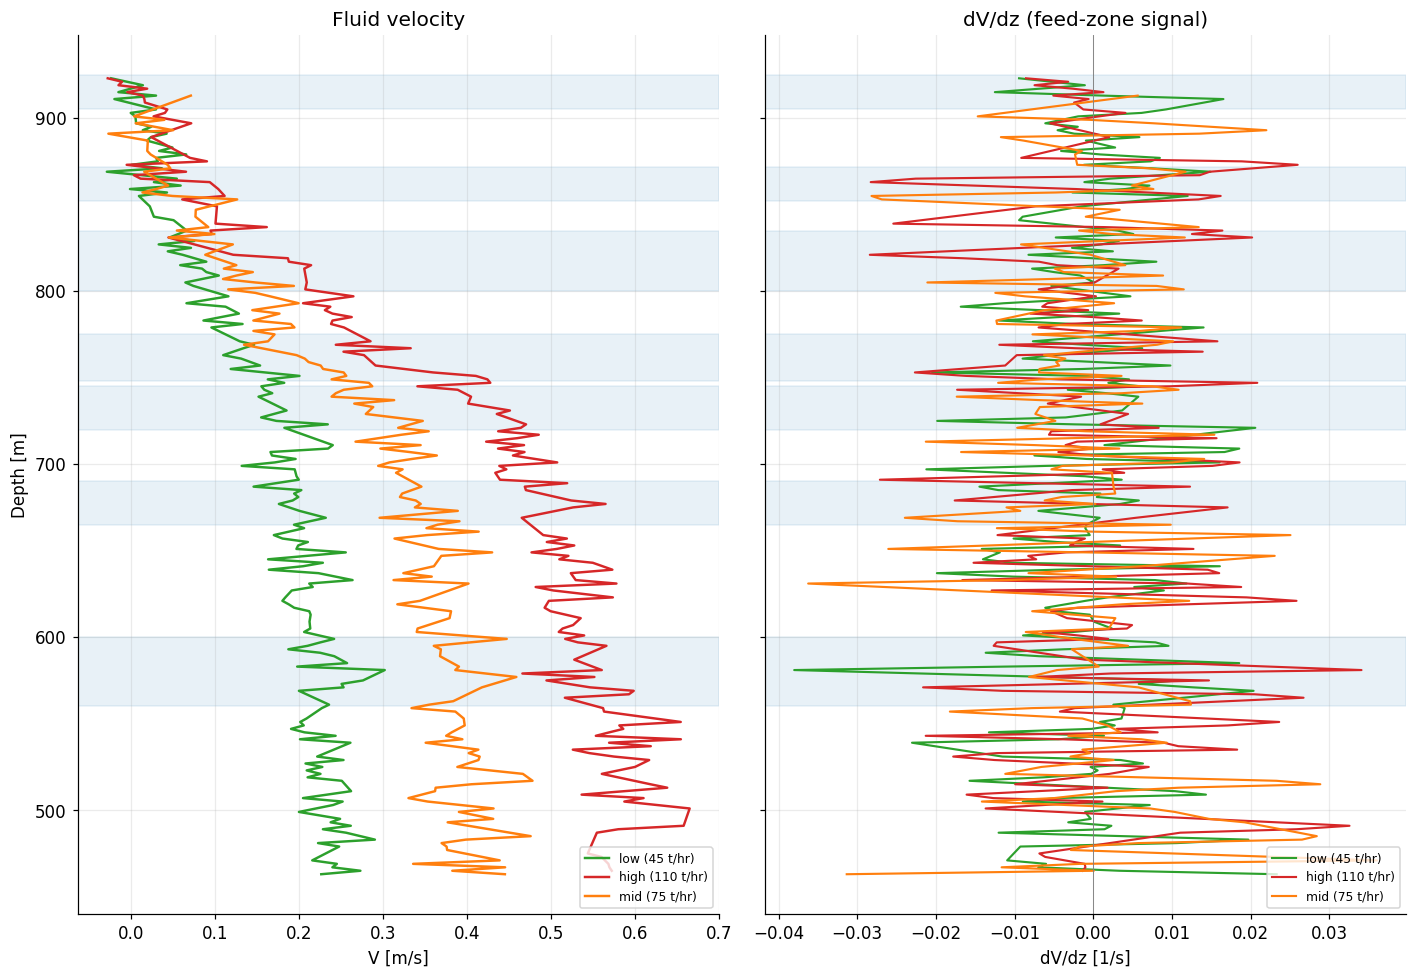

In [7]:
fig = plotting.plot_feedzone_signal(velocity, FEEDZONES)
plt.show()


## 4. Combine the results and find the feed zones

`combine_and_detect` fuses the temperature and velocity evidence into one score and returns the
confident feed zones (supported by **both** datasets), ranked by strength with their relative
injectivity.


Confident feed-zone depths: 584 m, 640 m, 700 m, 772 m, 802 m, 832 m, 868 m, 910 m


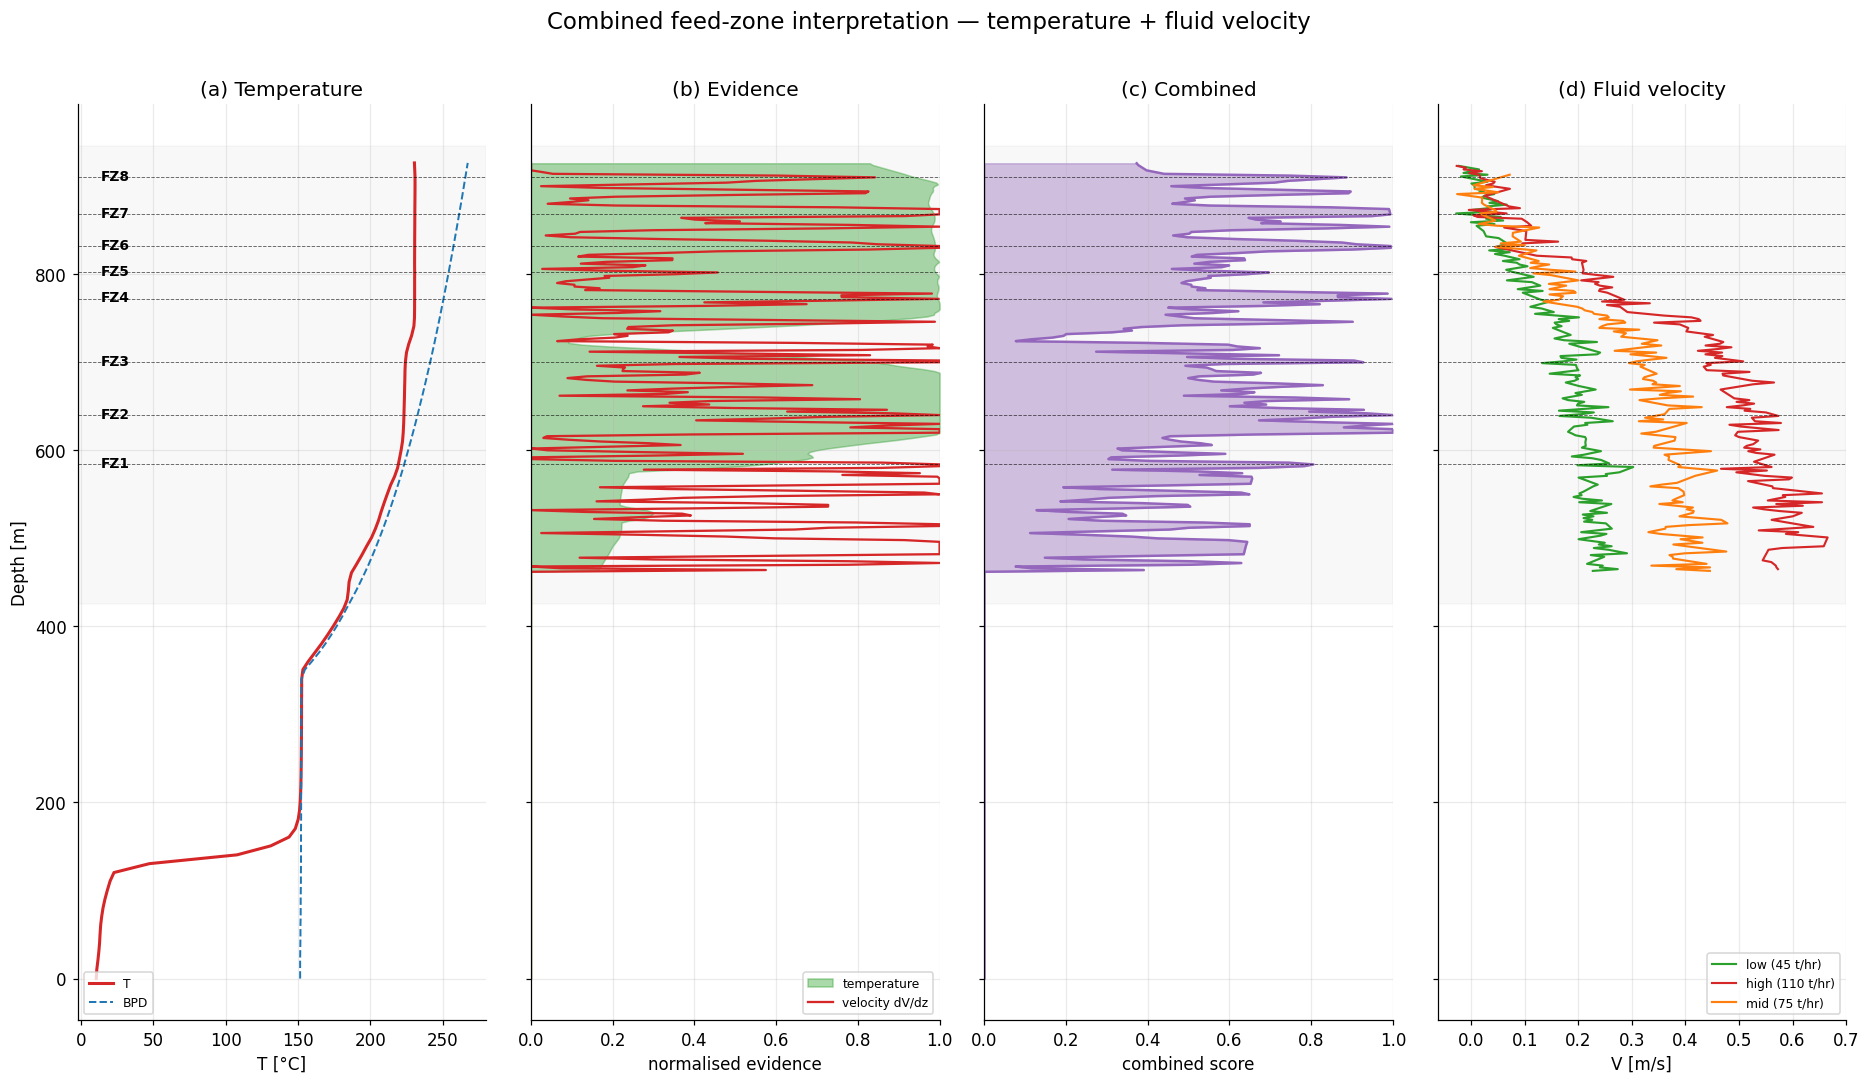

In [8]:
fz = combine_and_detect(temp.grad, velocity, FEEDZONES, DEFAULT_CONFIG, DEFAULT_GEOMETRY)
print("Confident feed-zone depths:", ", ".join(f"{d:.0f} m" for d in fz.picks_m))

fig = plotting.plot_combined_interpretation(df, temp, velocity, fz)
plt.show()


In [9]:
fz.table


,feed_zone,depth_m,combined_score,temp_evidence,vel_evidence,rel_injectivity
0,FZ2,640.0,1.00,1.00,1.00,NaN
1,FZ4,772.0,1.00,0.99,1.00,0.185
2,FZ7,868.0,0.99,0.99,1.00,0.026
3,FZ6,832.0,0.99,0.99,1.00,0.297
4,FZ3,700.0,0.93,0.84,1.00,0.103
5,FZ8,910.0,0.89,0.94,0.84,0.136
6,FZ1,584.0,0.81,0.57,1.00,0.120
7,FZ5,802.0,0.70,0.99,0.46,0.297


## 5. Summary

The heating profile shows a conductive cap over a broad convective/near-isothermal production
interval that tracks the boiling-point-for-depth curve. The spinner cross-plot recovers the
in-well fluid velocity, whose downward steps localise the feed zones and quantify their relative
injectivity. Fusing the two independent datasets yields feed-zone picks supported by both —
a more robust result than either alone.

**To run on real data:** replace `build_synthetic_pts` in Section 3 with your PTS import
(columns `depth_m, speed_mps, frequency_hz, pressure_bara` per logging pass) and re-run; the
temperature sections already operate on real logged data. See `docs/METHODOLOGY.md`.
